# Telecom Customer Churn Prediction - Logistic Regression

This notebook trains and evaluates a Logistic Regression model for predicting customer churn.

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
plt.style.use('ggplot')

## 1. Data Loading

In [2]:
# Load the dataset
data_path = '../Dataset/Processed_Telecom_Churn.csv'
df = pd.read_csv(data_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7032, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,0,1,0,1,0,1,29.85,29.85,True,...,False,False,False,False,False,False,False,True,False,0
1,1,0,0,0,34,1,0,56.95,1889.50,False,...,False,False,False,False,True,False,False,False,True,0
2,1,0,0,0,2,1,1,53.85,108.15,False,...,False,False,False,False,False,False,False,False,True,1
3,1,0,0,0,45,0,0,42.30,1840.75,True,...,False,False,False,False,True,False,False,False,False,0
4,0,0,0,0,2,1,1,70.70,151.65,False,...,False,False,False,False,False,False,False,True,False,1


## 2. Data Preparation
Here we will split the dataset into features (X) and the target variable (y), then segment it into training and testing portions. Finally, we apply feature scaling.

In [3]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Training set shape: (5625, 30)
Testing set shape: (1407, 30)


## 3. Model Training
We initialize our `LogisticRegression` class and fit it over the training sets.

In [4]:
# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


## 4. Model Evaluation
In this section, we predict testing sets and overview metrics like Accuracy, Precision, Recall, F1 Score, ROC-AUC and visual confusion matrix.

In [5]:
# Predict on the test set
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC-AUC Score:", roc_auc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7874911158493249
Precision: 0.6205787781350482
Recall: 0.516042780748663
F1-Score: 0.5635036496350365
ROC-AUC Score: 0.8319235288940887

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



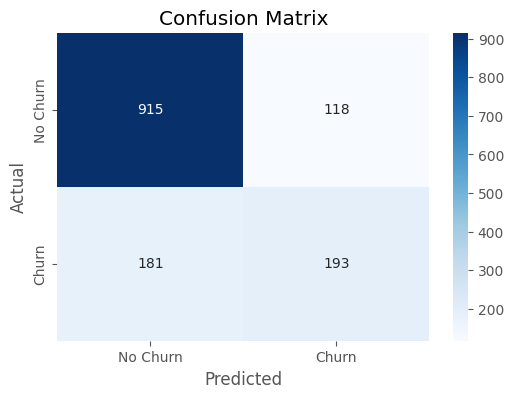

In [6]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 5. Export Predictions
Here we export the final predictions into a CSV file, similar to how the processed dataset was saved.

In [7]:
# Export predictions to CSV file
predictions_df = X_test.copy()
predictions_df['Actual_Churn'] = y_test
predictions_df['Predicted_Churn'] = y_pred
predictions_df['Predicted_Probability'] = np.round(y_pred_proba, 4)

# Create Results directory if it doesn't exist just in case
if not os.path.exists('../Results'):
    os.makedirs('../Results')

save_path = '../Results/Logistic_Regression_Predictions.csv'
predictions_df.to_csv(save_path, index=False)
print(f"Successfully saved predictions to: {save_path}")

# Create a dictionary of metrics
metrics_dict = {
    'Model': ['Logistic Regression'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-Score': [f1],
    'ROC-AUC': [roc_auc]
}

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_dict)

# Save to CSV
metrics_path = 'logistic_regression_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f"Evaluation metrics successfully exported to: {metrics_path}")

Successfully saved predictions to: ../Results/Logistic_Regression_Predictions.csv
Evaluation metrics successfully exported to: logistic_regression_metrics.csv
